# Workshop 1 : Image Processing

## 2.1 Exercise - 1


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

### 1. Read and display the image
Reading the image using **Pillow** library.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import os
print(os.listdir("/content/drive/MyDrive/AI & ML/workshop1"))


['cameraman.png', 'lena_gray.gif']


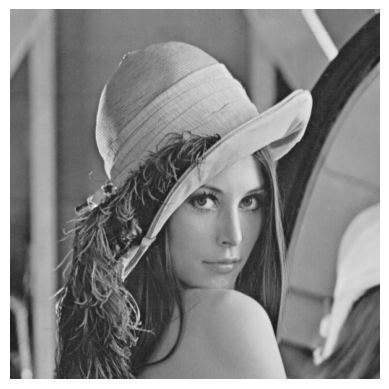

In [13]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open("/content/drive/MyDrive/AI & ML/workshop1/lena_gray.gif").convert("RGB")

plt.imshow(image)
plt.axis("off")
plt.show()

### 2. Display only the top left corner of 100x100 pixels


(np.float64(-0.5), np.float64(99.5), np.float64(99.5), np.float64(-0.5))

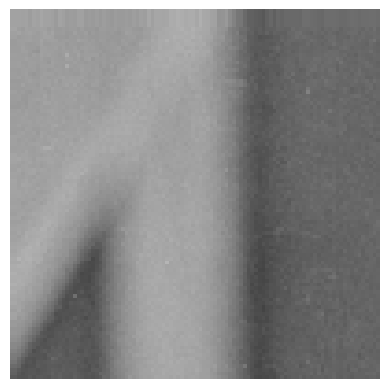

In [12]:
img_array = np.array(image)
top_left = img_array[:100, :100]

plt.imshow(top_left)
plt.axis('off')

### 3. Show the three color channels (R, G, B)


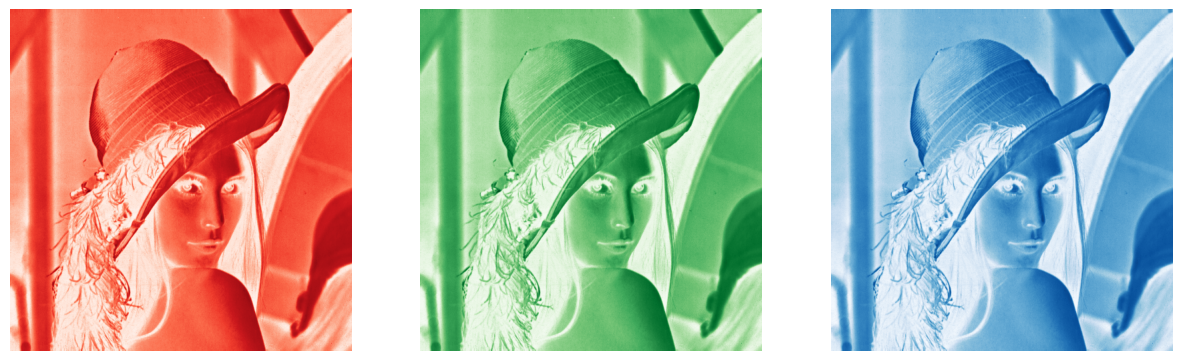

In [14]:
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(R, cmap='Reds')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(G, cmap='Greens')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(B, cmap='Blues')
plt.axis('off')

plt.show()

### 4. Modify the top 100x100 pixels to a value of 210


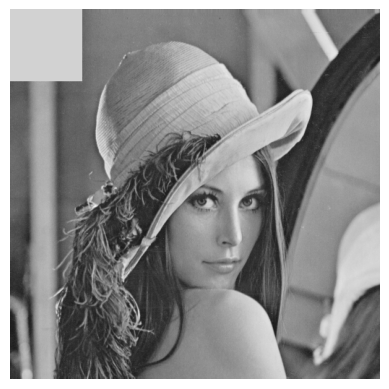

In [15]:
modified_img = img_array.copy()
modified_img[:100, :100] = 210

plt.imshow(modified_img)
plt.axis('off')
plt.show()

## 2.2 Exercise - 2


In [19]:
image_path = "/content/drive/MyDrive/AI & ML/workshop1/cameraman.png"


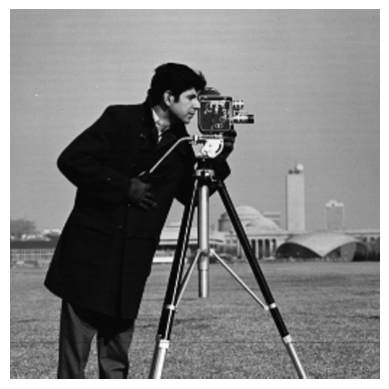

In [24]:
from PIL import Image
import matplotlib.pyplot as plt

# Full path to the image in Google Drive
image_path = "/content/drive/MyDrive/AI & ML/workshop1/cameraman.png"

# Open the image in grayscale using the correct path
gray_image = Image.open(image_path).convert("L")

# Display the image
plt.imshow(gray_image, cmap='gray')
plt.axis('off')
plt.show()

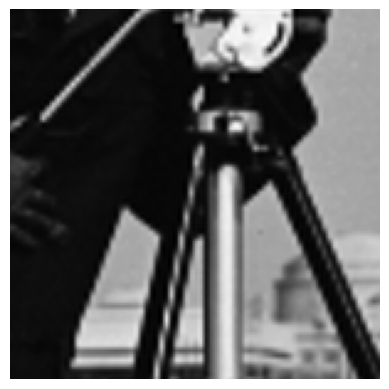

In [25]:
gray_array = np.array(gray_image)
h, w = gray_array.shape
start_h, start_w = h // 2 - 75, w // 2 - 75
middle_section = gray_array[start_h:start_h+150, start_w:start_w+150]

plt.imshow(middle_section, cmap='gray')
plt.axis('off')
plt.show()

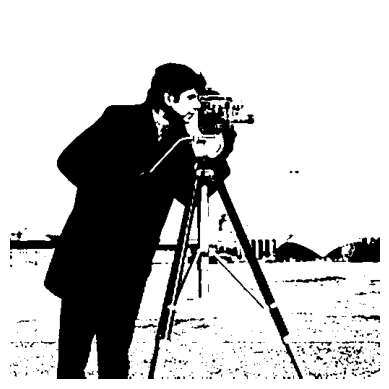

In [26]:
thresholded = np.where(gray_array < 100, 0, 255)

plt.imshow(thresholded, cmap='gray')
plt.axis('off')
plt.show()

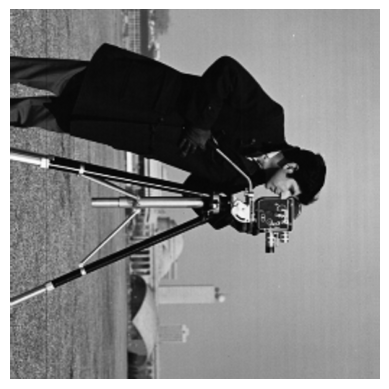

In [27]:
rotated_image = gray_image.rotate(-90)

plt.imshow(rotated_image, cmap='gray')
plt.axis('off')
plt.show()

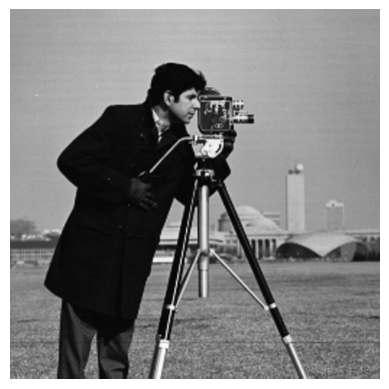

In [28]:
rgb_converted = np.stack([gray_array] * 3, axis=-1)

plt.imshow(rgb_converted)
plt.axis('off')
plt.show()

## Exercise 3

In [32]:
from PIL import Image
import numpy as np

# Full path to the image in your Drive
image_path = "/content/drive/MyDrive/AI & ML/workshop1/lena_gray.gif"

# Open the image in grayscale
img_gray = Image.open(image_path).convert("L")

# Convert image to numpy array
img_arr = np.array(img_gray, dtype=float)

print("Image shape:", img_arr.shape)

Image shape: (512, 512)


In [33]:
mean_centered_data = img_arr - np.mean(img_arr, axis=0)

In [34]:
cov_matrix = np.cov(mean_centered_data, rowvar=False)

In [35]:
eigen_values, eigen_vectors = np.linalg.eigh(cov_matrix)

In [36]:
sorted_index = np.argsort(eigen_values)[::-1]
sorted_eigenvalue = eigen_values[sorted_index]
sorted_eigenvectors = eigen_vectors[:, sorted_index]

In [37]:
cumulative_variance = np.cumsum(sorted_eigenvalue) / np.sum(sorted_eigenvalue)

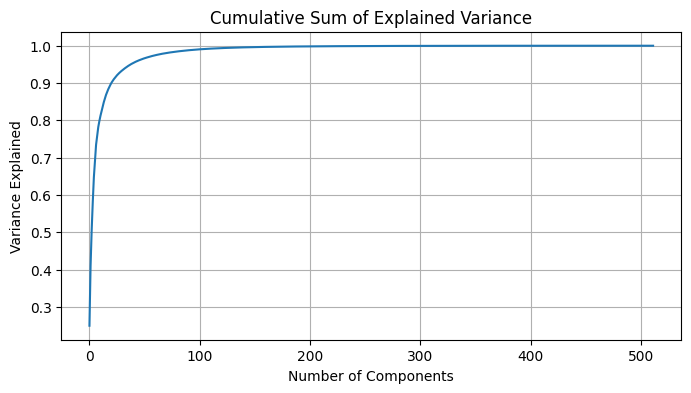

In [38]:
plt.figure(figsize=(8, 4))
plt.plot(cumulative_variance)
plt.title('Cumulative Sum of Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Variance Explained')
plt.grid()
plt.show()

In [39]:
def compress_decompress(data, components, sorted_eigenvectors, original_mean):
    subset_vectors = sorted_eigenvectors[:, :components]
    transformed_data = np.dot(data, subset_vectors)

    reconstructed_data = np.dot(transformed_data, subset_vectors.T) + original_mean
    return reconstructed_data

In [40]:
component_list = [10, 20, 50, 100]
original_mean = np.mean(img_arr, axis=0)

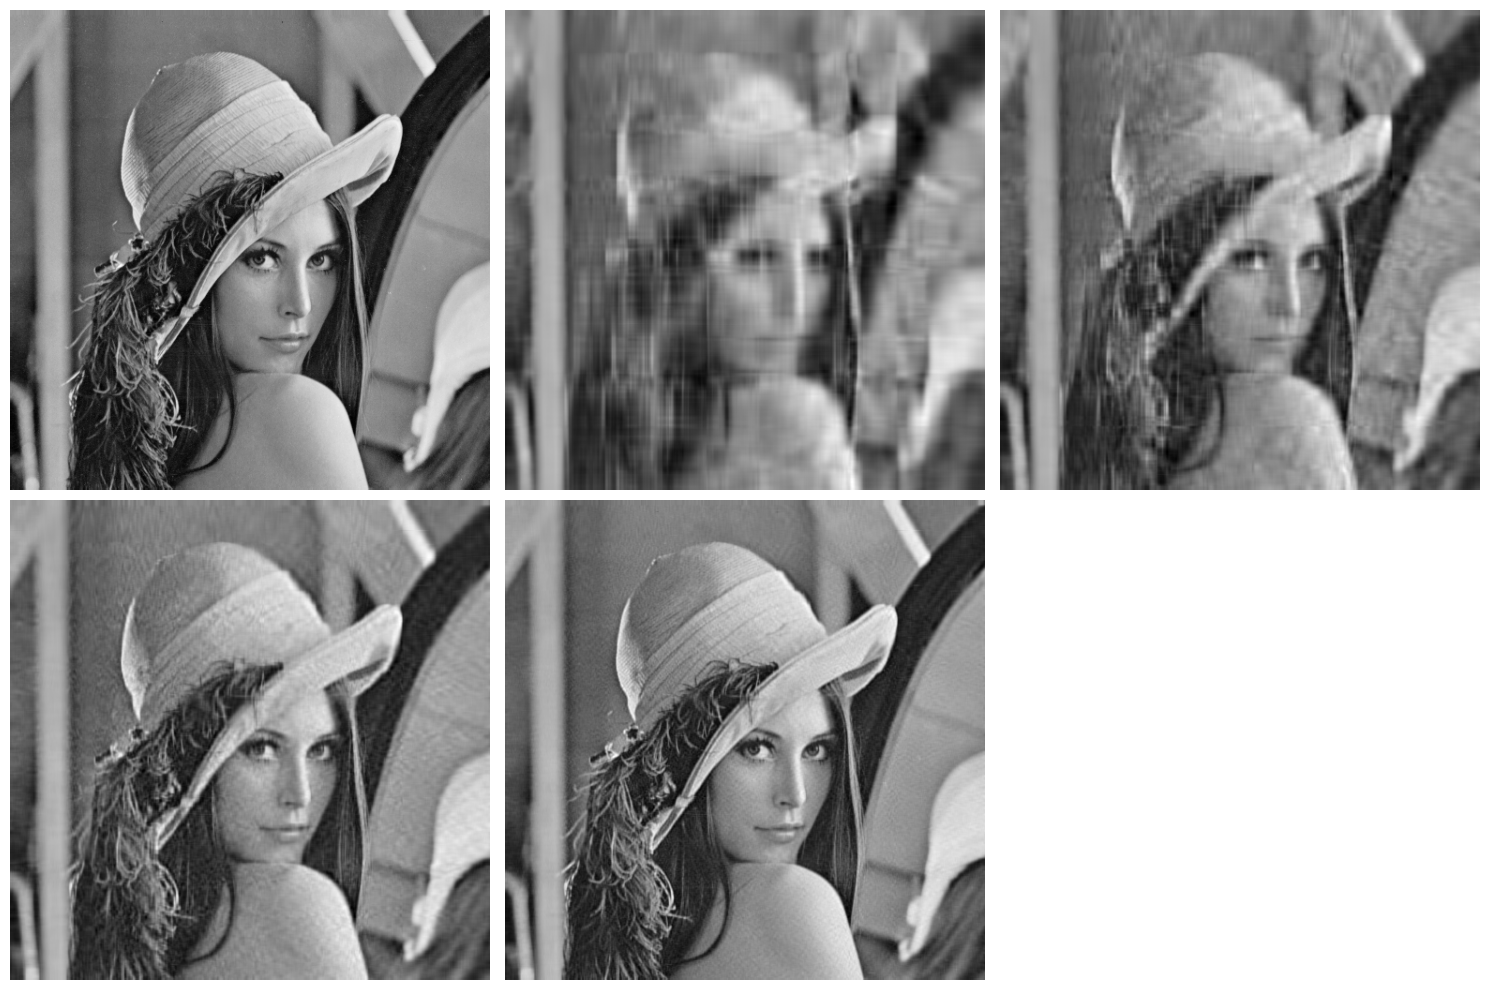

In [41]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 3, 1)
plt.imshow(img_arr, cmap='gray')
plt.axis('off')

for i, k in enumerate(component_list):
    reconstructed = compress_decompress(mean_centered_data, k, sorted_eigenvectors, original_mean)

    plt.subplot(2, 3, i+2)
    plt.imshow(reconstructed, cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()